# Database overview
Summarises table sizes, field coverage, top work types and polity coverage of the Cultura V2 database.

In [1]:
import json
import random
import tempfile
import numpy as np
import polars as pl
import duckdb
import matplotlib.pyplot as plt
from style import *

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DB_PATH = '../data/cultura/humans_clean_v2.duckdb'
WORK_TYPE_LABELS_PATH = '../data/raw_data_from_wikidata/wikidata_extraction_scripts_v2/work_instance_labels.json'

BUCKET_YEARS = 50
YEAR_MIN, YEAR_MAX = -3500, 2025
MIN_INDIVIDUALS_PER_BUCKET = 5

FICTIONAL_PLACE_TYPES = {
    'Q1145276': 'fictional country',
    'Q117818123': 'country which may be fictional',
    'Q3895768': 'fictional location',
    'Q559618': 'fictional universe',
}

pl.Config.set_tbl_rows(30)
pl.Config.set_fmt_str_lengths(60)

apply_style()

## External data — Wikidata work-type labels

## Connect

In [2]:
con = duckdb.connect(DB_PATH, read_only=True)
con.sql(f"SET memory_limit='4GB'; SET threads=6; SET temp_directory='{tempfile.mkdtemp()}';")

## Load data
### Field coverage

In [3]:
field_coverage_wide = con.sql('''
    SELECT
        COUNT(*)                                                   AS total_individuals,
        COUNT(*) FILTER (WHERE len(i.birth_date) > 0)              AS date_of_birth,
        COUNT(*) FILTER (WHERE len(i.death_date) > 0)              AS date_of_death,
        COUNT(*) FILTER (WHERE len(i.floruit_date) > 0)            AS floruit_date,
        COUNT(i.place_of_birth.entity.qid)                         AS place_of_birth,
        COUNT(i.place_of_death.entity.qid)                         AS place_of_death,
        COUNT(*) FILTER (WHERE len(i.country_of_citizenship) > 0)  AS nationality,
        COUNT(*) FILTER (WHERE len(i.occupation) > 0)              AS occupation,
        COUNT(i.sex_or_gender)                                     AS gender,
        COUNT(*) FILTER (WHERE len(i.writing_language) > 0)        AS writing_language,
        COUNT(*) FILTER (WHERE len(i.sitelink) > 0)                AS wikimedia_sitelinks,
        COUNT(*) FILTER (WHERE len(i.external_id) > 0)             AS external_identifiers,
        COUNT(e.peak_productivity.start_year)                      AS peak_productivity_window,
        COUNT(*) FILTER (WHERE e.polity_count > 0)                 AS cliopatria_polity_mapping
    FROM individual AS i
    JOIN individual_enriched AS e
      ON e.entity.qid = i.entity.qid
''').pl()

print('shape:', field_coverage_wide.shape)
field_coverage_wide

shape: (1, 14)


total_individuals,date_of_birth,date_of_death,floruit_date,place_of_birth,place_of_death,nationality,occupation,gender,writing_language,wikimedia_sitelinks,external_identifiers,peak_productivity_window,cliopatria_polity_mapping
i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
13002897,7490137,3532432,70521,3724787,1585483,5570031,9038108,8965424,225825,4959581,8738235,9709528,5158972


### Core counts

In [4]:
CORE_COUNT_QUERIES = {
    'individual':                          'SELECT COUNT(*) FROM individual',
    'individual (is_human = false)':       'SELECT COUNT(*) FROM individual WHERE NOT is_human',
    'place':                               'SELECT COUNT(*) FROM place',
    'place (is_settlement)':               'SELECT COUNT(*) FROM place WHERE is_settlement',
    'occupation':                          'SELECT COUNT(*) FROM occupation',
    'writing languages (distinct)':        'SELECT COUNT(DISTINCT language) FROM (SELECT unnest(writing_language) AS language FROM individual)',
    'countries of citizenship (distinct)': 'SELECT COUNT(DISTINCT country_qid) FROM (SELECT unnest(country_of_citizenship).entity.qid AS country_qid FROM individual)',
    'individual_identifier':               'SELECT COUNT(*) FROM individual_identifier',
    'identifier':                          'SELECT COUNT(*) FROM identifier',
    'individual_sitelink':                 'SELECT COUNT(*) FROM individual_sitelink',
    'sitelink':                            'SELECT COUNT(*) FROM sitelink',
    'work':                                'SELECT COUNT(*) FROM work',
    'individual_work':                     'SELECT COUNT(*) FROM individual_work',
    'individual x polity links':           'SELECT SUM(polity_count)::BIGINT FROM individual_enriched',
    'polity':                              'SELECT COUNT(*) FROM polity',
}

core_counts = pl.DataFrame({
    'table_name': list(CORE_COUNT_QUERIES),
    'rows': [con.sql(query).fetchone()[0] for query in CORE_COUNT_QUERIES.values()],
})

print('shape:', core_counts.shape)
core_counts

shape: (15, 2)


table_name,rows
str,i64
"""individual""",13002897
"""individual (is_human = false)""",57
"""place""",316306
"""place (is_settlement)""",257269
"""occupation""",18227
"""writing languages (distinct)""",524
"""countries of citizenship (distinct)""",3640
"""individual_identifier""",36880469
"""identifier""",10198


### Coverage criteria

In [5]:
coverage_criteria_wide = con.sql('''
    WITH flags AS (
        SELECT
            place_of_birth.entity.qid IS NOT NULL
                OR place_of_death.entity.qid IS NOT NULL
                OR len(country_of_citizenship) > 0                         AS has_place,
            len(birth_date) > 0 OR len(death_date) > 0 OR len(floruit_date) > 0  AS has_date,
            len(external_id) > 0 OR len(sitelink) > 0                      AS has_link
        FROM individual
    )
    SELECT
        COUNT(*) FILTER (WHERE has_place)                            AS any_place,
        COUNT(*) FILTER (WHERE has_date)                             AS any_date,
        COUNT(*) FILTER (WHERE has_link)                             AS any_identifier_or_sitelink,
        COUNT(*) FILTER (WHERE has_place AND has_date AND has_link)  AS place_and_date_and_link
    FROM flags
''').pl()

coverage_criteria_wide

any_place,any_date,any_identifier_or_sitelink,place_and_date_and_link
i64,i64,i64,i64
6376666,7798532,9547626,4865405


### Flagged non-historical entries

In [6]:
n_non_human = con.sql('''
    SELECT COUNT(*)
    FROM individual
    WHERE NOT is_human
''').fetchone()[0]

con.sql('''
    CREATE OR REPLACE TEMP TABLE fictional_place AS
    SELECT DISTINCT place_qid
    FROM (
        SELECT entity.qid AS place_qid, unnest(instance_of).qid AS type_qid
        FROM place
    )
    WHERE list_contains($fictional_types, type_qid)
''', params={'fictional_types': list(FICTIONAL_PLACE_TYPES)})

n_fictional_countries = con.sql('''
    SELECT COUNT(DISTINCT country_qid)
    FROM (SELECT unnest(country_of_citizenship).entity.qid AS country_qid FROM individual)
    WHERE country_qid IN (SELECT place_qid FROM fictional_place)
''').fetchone()[0]

removed_entries = pl.DataFrame({
    'filter': [
        'is_human = false (fictional / mythical / legendary / deity)',
        'country_of_citizenship instance_of = fictional polity',
    ],
    'count': [n_non_human, n_fictional_countries],
})

removed_entries

filter,count
str,i64
"""is_human = false (fictional / mythical / legendary / deity)""",57
"""country_of_citizenship instance_of = fictional polity""",0


### Top 20 work types

In [7]:
top_work_type_qids = con.sql('''
    SELECT
        work_type.qid AS work_type_qid,
        COUNT(*)      AS n_works
    FROM (SELECT unnest(instance_of) AS work_type FROM work)
    WHERE work_type.qid IS NOT NULL
    GROUP BY work_type_qid
    ORDER BY n_works DESC
    LIMIT 20
''').pl()

with open(WORK_TYPE_LABELS_PATH) as f:
    wikidata_work_type_labels = json.load(f)

work_type_labels = pl.DataFrame({
    'work_type_qid': top_work_type_qids['work_type_qid'],
    'work_type': [wikidata_work_type_labels.get(q) for q in top_work_type_qids['work_type_qid']],
})

assert work_type_labels['work_type_qid'].is_unique().all()
top_work_type_qids.head()

work_type_qid,n_works
str,i64
"""Q13442814""",12949085
"""Q3305213""",739305
"""Q3331189""",480959
"""Q7725634""",415445
"""Q11424""",267356


### Individuals per 50-year bucket

In [8]:
bucket_counts = con.sql('''
    SELECT
        CAST(FLOOR(peak_productivity.start_year / $bucket_years) * $bucket_years AS INTEGER) AS bucket,
        COUNT(*)                                  AS total_with_window,
        COUNT(*) FILTER (WHERE polity_count > 0)  AS individuals_with_polity
    FROM individual_enriched
    WHERE peak_productivity.start_year BETWEEN $year_min AND $year_max
    GROUP BY bucket
    ORDER BY bucket
''', params={'bucket_years': BUCKET_YEARS, 'year_min': YEAR_MIN, 'year_max': YEAR_MAX}).pl()

print('shape:', bucket_counts.shape)
bucket_counts.head()

shape: (107, 3)


bucket,total_with_window,individuals_with_polity
i32,i64,i64
-3500,11,0
-3250,1,0
-3200,3,0
-3150,6,0
-3100,6,0


### 20 famous polities

In [9]:
FAMOUS_POLITIES = [
    (6, 'Akkadian Empire'), (23, 'New Kingdom of Egypt'), (91, 'Achaemenid Empire'),
    (65, 'Macedonian Empire'), (93, 'Roman Republic'), (114, 'Ptolemaic Kingdom'),
    (204, 'Roman Empire'), (223, 'Sasanian Empire'), (366, 'Tang Dynasty'),
    (402, 'Carolingian Empire'), (414, 'Abbasid Caliphate'), (373, 'Byzantine Empire'),
    (729, 'Mongol Empire'), (397, 'Republic of Venice'), (523, 'Holy Roman Empire'),
    (896, 'Ming Dynasty'), (839, 'Ottoman Empire'), (1050, 'Tokugawa Shogunate'),
    (1117, 'Russian Empire'), (1102, 'Kingdom of Great Britain'),
]
famous_polity_ids = [polity_id for polity_id, _ in FAMOUS_POLITIES]
famous_polity_names = pl.DataFrame(FAMOUS_POLITIES, schema=['polity_id', 'polity_name'], orient='row')

polity_periods = con.sql('''
    WITH famous_territory AS (
        SELECT cliopatria_id, name, unnest(territories) AS territory
        FROM polity
        WHERE list_contains($ids, cliopatria_id)
    )
    SELECT
        cliopatria_id             AS polity_id,
        name                      AS db_name,
        MIN(territory.start_year) AS year_start,
        MAX(territory.end_year)   AS year_end
    FROM famous_territory
    GROUP BY cliopatria_id, name
    ORDER BY polity_id
''', params={'ids': famous_polity_ids}).pl()

assert polity_periods.height == len(FAMOUS_POLITIES)
polity_periods.head()

polity_id,db_name,year_start,year_end
i64,str,i64,i64
6,"""Akkadian Empire""",-2300,-2101
23,"""New Kingdom of Egypt""",-1500,-801
65,"""Macedonian Empire""",-675,-292
91,"""Achaemenid Empire""",-550,-327
93,"""Roman Republic""",-500,-32


### Most notable individual per polity

In [10]:
top_qid_per_polity = con.sql('''
    WITH polity_link AS (
        SELECT
            entity.qid                                 AS qid,
            notability.cross_cultural_score            AS score,
            unnest(polity).polity.cliopatria_id        AS polity_id
        FROM individual_enriched
        WHERE polity_count > 0
    )
    SELECT
        polity_id,
        ARG_MAX(qid, score) AS qid
    FROM polity_link
    WHERE list_contains($ids, polity_id)
    GROUP BY polity_id
''', params={'ids': famous_polity_ids}).pl()

notable_individuals = con.sql('''
    SELECT
        i.entity.qid                                   AS qid,
        i.entity.label_en                              AS name_en,
        i.entity.description                           AS description_en,
        i.birth_date[1].year                           AS birth_year,
        i.death_date[1].year                           AS death_year,
        e.notability.cross_cultural_score              AS cross_cultural_score,
        e.notability.number_of_western_editions        AS western_editions,
        e.notability.number_of_non_western_editions    AS non_western_editions,
        len(i.sitelink)                                AS sitelinks
    FROM individual AS i
    JOIN individual_enriched AS e
      ON e.entity.qid = i.entity.qid
    WHERE list_contains($qids, i.entity.qid)
''', params={'qids': top_qid_per_polity['qid'].to_list()}).pl()

con.close()
notable_individuals.head()

qid,name_en,description_en,birth_year,death_year,cross_cultural_score,western_editions,non_western_editions,sitelinks
str,str,str,i64,i64,f64,i64,i64,i64
"""Q12154""","""TutanKhamun""","""14th century BCE (18th dynasty) Egyptian pharaoh""",-1340,-1323,47.47631,46,49,114
"""Q199461""","""Sargon of Akkad""","""founder of Akkadian Empire""",-2350,-2300,33.941125,36,32,78
"""Q1048""","""Julius Caesar""","""Roman general and dictator""",-99,-43,69.935685,67,73,280
"""Q1398""","""Virgil""","""Roman poet (1st century BC)""",-69,-18,58.395205,62,55,243
"""Q8409""","""Alexander the Great""","""king of Macedonia and conqueror of Achaemenid Persia (356â…",-355,-322,67.734777,62,74,259


## Preprocessing

### Field coverage table

In [11]:
PROPERTY_LABELS = {
    'total_individuals': 'Total individuals',
    'date_of_birth': 'Date of birth',
    'date_of_death': 'Date of death',
    'floruit_date': 'Floruit date',
    'place_of_birth': 'Place of birth',
    'place_of_death': 'Place of death',
    'nationality': 'Nationality',
    'occupation': 'Occupation',
    'gender': 'Gender',
    'writing_language': 'Writing language',
    'wikimedia_sitelinks': 'Wikimedia sitelinks (>=1)',
    'external_identifiers': 'External identifiers (>=1)',
    'peak_productivity_window': 'Peak-productivity window (computed)',
    'cliopatria_polity_mapping': 'Cliopatria polity mapping',
}

total_individuals = field_coverage_wide['total_individuals'].item()

def to_long(wide, key, value):
    return (
        wide.transpose(include_header=True, header_name=key, column_names=[value])
        .with_columns((pl.col(value).cast(pl.Float64) / total_individuals * 100).round(1).alias('% of total'))
    )

field_coverage = to_long(field_coverage_wide, 'Property', 'Individuals').with_columns(pl.col('Property').replace(PROPERTY_LABELS))
assert field_coverage['% of total'].max() <= 100
field_coverage.head()

Property,Individuals,% of total
str,i64,f64
"""Total individuals""",13002897,100.0
"""Date of birth""",7490137,57.6
"""Date of death""",3532432,27.2
"""Floruit date""",70521,0.5
"""Place of birth""",3724787,28.6


### Coverage criteria table

In [12]:
coverage_criteria = to_long(coverage_criteria_wide, 'criterion', 'individuals')
coverage_criteria.head()

criterion,individuals,% of total
str,i64,f64
"""any_place""",6376666,49.0
"""any_date""",7798532,60.0
"""any_identifier_or_sitelink""",9547626,73.4
"""place_and_date_and_link""",4865405,37.4


### Work type labels

In [13]:
top_work_types = (
    top_work_type_qids
    .join(work_type_labels, on='work_type_qid', how='left')
    .select('work_type_qid', 'work_type', 'n_works')
    .sort('n_works', descending=True)
)
assert top_work_types.height == top_work_type_qids.height
assert top_work_types['work_type'].null_count() == 0
top_work_types.head()

work_type_qid,work_type,n_works
str,str,i64
"""Q13442814""","""scholarly article""",12949085
"""Q3305213""","""painting""",739305
"""Q3331189""","""version, edition or translation""",480959
"""Q7725634""","""literary work""",415445
"""Q11424""","""film""",267356


### Polity share per bucket

In [14]:
last_complete_bucket = (YEAR_MAX + 1) // BUCKET_YEARS * BUCKET_YEARS - BUCKET_YEARS
print('buckets before filter:', bucket_counts.height)

polity_share_per_bucket = (
    bucket_counts
    .filter(pl.col('bucket') <= last_complete_bucket)
    .filter(pl.col('total_with_window') >= MIN_INDIVIDUALS_PER_BUCKET)
    .with_columns((pl.col('individuals_with_polity') / pl.col('total_with_window') * 100).round(1).alias('pct_with_polity'))
)
print('buckets after filter:', polity_share_per_bucket.height)

overall_pct = polity_share_per_bucket['individuals_with_polity'].sum() / polity_share_per_bucket['total_with_window'].sum() * 100
print(f'overall coverage: {overall_pct:.1f}%')
assert polity_share_per_bucket['pct_with_polity'].is_between(0, 100).all()
polity_share_per_bucket.tail()

buckets before filter: 107
buckets after filter: 101
overall coverage: 65.1%


bucket,total_with_window,individuals_with_polity,pct_with_polity
i32,i64,i64,f64
1750,175817,93473,53.2
1800,314007,185428,59.1
1850,647389,427350,66.0
1900,1444956,1003631,69.5
1950,2838887,1909196,67.3


### Notable individuals table

In [15]:
def format_year(year):
    if year is None:
        return '?'
    return f'{abs(year)} BCE' if year < 0 else f'{year} CE'

notable_per_polity = (
    famous_polity_names
    .join(polity_periods, on='polity_id', how='left')
    .join(top_qid_per_polity, on='polity_id', how='left')
    .join(notable_individuals, on='qid', how='left')
    .sort('year_start')
    .with_columns(
        pl.struct('year_start', 'year_end').map_elements(
            lambda r: f"{format_year(r['year_start'])} – {format_year(r['year_end'])}", return_dtype=pl.String).alias('period'),
        pl.struct('birth_year', 'death_year').map_elements(
            lambda r: f"{format_year(r['birth_year'])} – {format_year(r['death_year'])}", return_dtype=pl.String).alias('lifespan'),
        pl.col('cross_cultural_score').round(1),
    )
    .select('polity_name', 'period', 'name_en', 'lifespan', 'description_en',
            'cross_cultural_score', 'western_editions', 'non_western_editions', 'sitelinks')
)
assert notable_per_polity.height == len(FAMOUS_POLITIES)

## Tables

### Table 1 — Field coverage

In [16]:
field_coverage

Property,Individuals,% of total
str,i64,f64
"""Total individuals""",13002897,100.0
"""Date of birth""",7490137,57.6
"""Date of death""",3532432,27.2
"""Floruit date""",70521,0.5
"""Place of birth""",3724787,28.6
"""Place of death""",1585483,12.2
"""Nationality""",5570031,42.8
"""Occupation""",9038108,69.5
"""Gender""",8965424,68.9


### Table 2 — Core counts

In [17]:
core_counts

table_name,rows
str,i64
"""individual""",13002897
"""individual (is_human = false)""",57
"""place""",316306
"""place (is_settlement)""",257269
"""occupation""",18227
"""writing languages (distinct)""",524
"""countries of citizenship (distinct)""",3640
"""individual_identifier""",36880469
"""identifier""",10198


### Table 3 — Coverage criteria

In [18]:
coverage_criteria

criterion,individuals,% of total
str,i64,f64
"""any_place""",6376666,49.0
"""any_date""",7798532,60.0
"""any_identifier_or_sitelink""",9547626,73.4
"""place_and_date_and_link""",4865405,37.4


### Table 4 — Flagged entries

In [19]:
removed_entries

filter,count
str,i64
"""is_human = false (fictional / mythical / legendary / deity)""",57
"""country_of_citizenship instance_of = fictional polity""",0


### Table 5 — Top 20 work types

In [20]:
top_work_types

work_type_qid,work_type,n_works
str,str,i64
"""Q13442814""","""scholarly article""",12949085
"""Q3305213""","""painting""",739305
"""Q3331189""","""version, edition or translation""",480959
"""Q7725634""","""literary work""",415445
"""Q11424""","""film""",267356
"""Q482994""","""album""",171639
"""Q11060274""","""print""",131935
"""Q13433827""","""encyclopedia article""",130067
"""Q105543609""","""musical work/composition""",129746


### Table 6 — Most notable individual per polity

In [21]:
with pl.Config(tbl_rows=-1, tbl_cols=-1, tbl_width_chars=240, fmt_str_lengths=50):
    print(notable_per_polity)

shape: (20, 9)
┌──────────────────────────┬─────────────────────┬─────────────────────┬─────────────────────┬─────────────────────────────────────────────────────┬──────────────────────┬──────────────────┬──────────────────────┬───────────┐
│ polity_name              ┆ period              ┆ name_en             ┆ lifespan            ┆ description_en                                      ┆ cross_cultural_score ┆ western_editions ┆ non_western_editions ┆ sitelinks │
│ ---                      ┆ ---                 ┆ ---                 ┆ ---                 ┆ ---                                                 ┆ ---                  ┆ ---              ┆ ---                  ┆ ---       │
│ str                      ┆ str                 ┆ str                 ┆ str                 ┆ str                                                 ┆ f64                  ┆ i64              ┆ i64                  ┆ i64       │
╞══════════════════════════╪═════════════════════╪═════════════════════╪═════════

## Figures

### Fig 1 — Individuals with a polity (log scale)

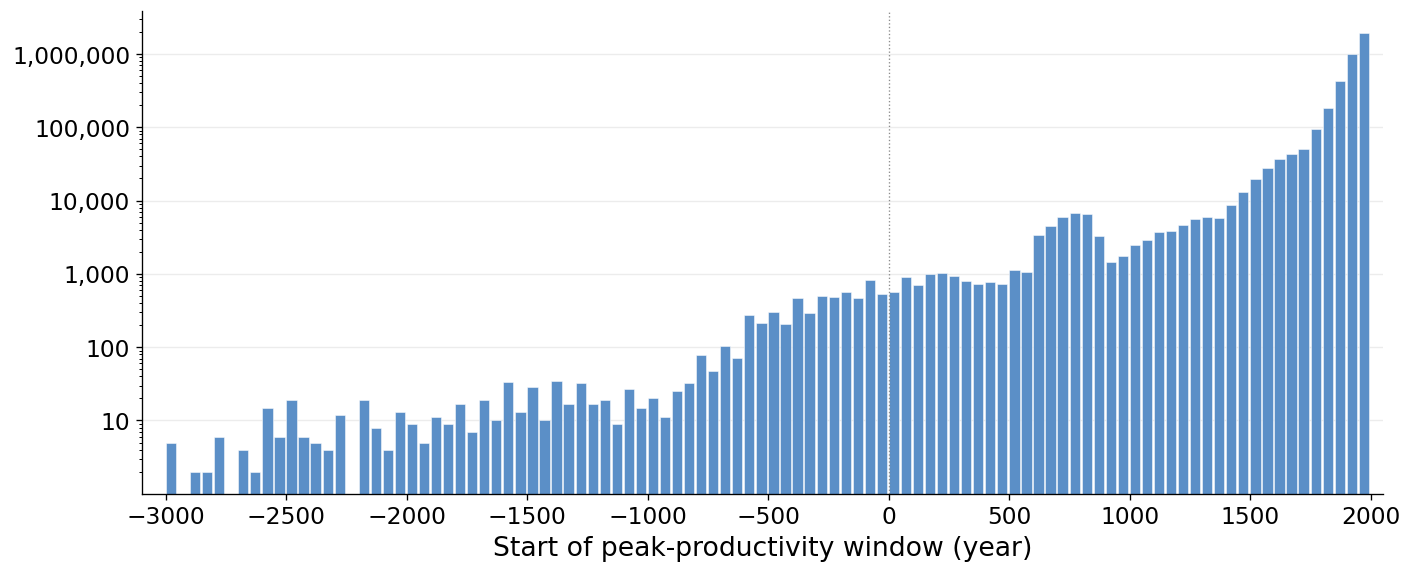

In [22]:
fig, ax = plt.subplots()
ax.bar(polity_share_per_bucket['bucket'], polity_share_per_bucket['individuals_with_polity'],
       width=BUCKET_YEARS * 0.85, align='edge', color=MAIN_COLOR, edgecolor=BACKGROUND_COLOR, linewidth=0.3)
ax.set_yscale('log')
ax.yaxis.set_major_formatter(THOUSANDS)
ax.set_xlabel('Start of peak-productivity window (year)')
ax.set_xticks(range(-3000, 2001, 500))
ax.set_xlim(-3100, 2050)
ax.grid(axis='y')
ax.axvline(0, **REFERENCE_LINE)
plt.tight_layout()
plt.show()

### Fig 2 — Share of individuals with a polity

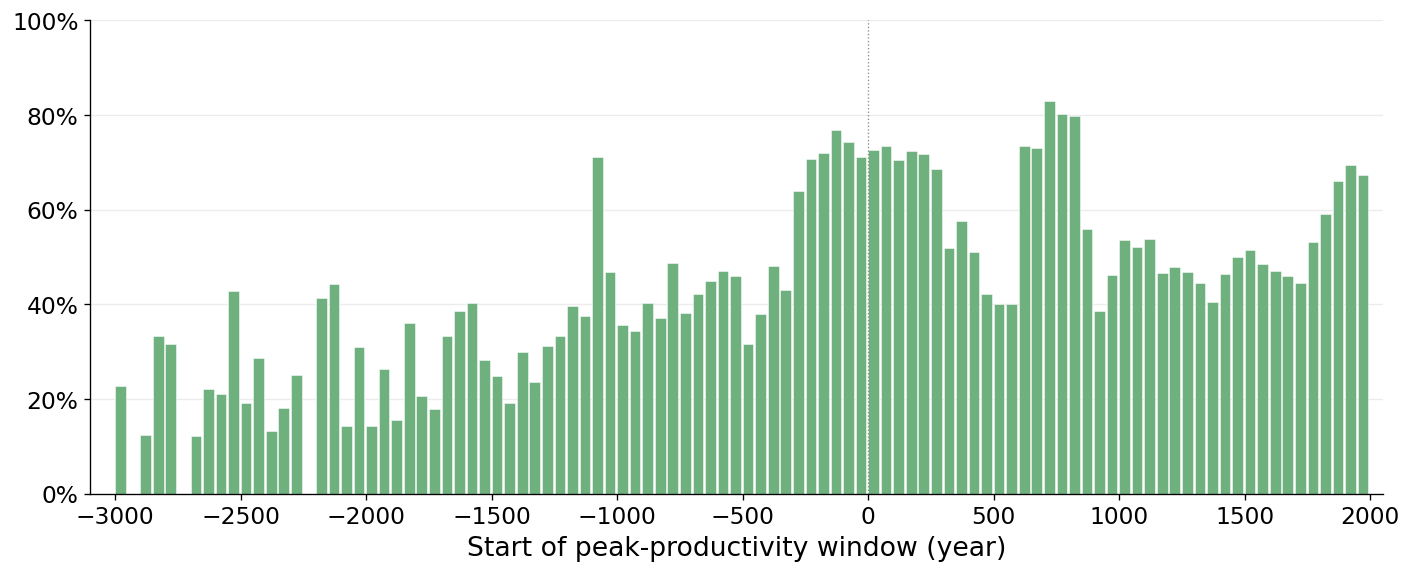

In [23]:
fig, ax = plt.subplots()
ax.bar(polity_share_per_bucket['bucket'], polity_share_per_bucket['pct_with_polity'],
       width=BUCKET_YEARS * 0.85, align='edge', color=POLITY_MATCH_COLORS['with_polity'], edgecolor=BACKGROUND_COLOR, linewidth=0.3)
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(PERCENT)
ax.set_xlabel('Start of peak-productivity window (year)')
ax.set_xticks(range(-3000, 2001, 500))
ax.set_xlim(-3100, 2050)
ax.grid(axis='y')
ax.axvline(0, **REFERENCE_LINE)
plt.tight_layout()
plt.show()